## Load Libraries

In [1]:
# Ensure local package path is first
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import libraries
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir
import importlib

# Reload to pick up code changes
import galform_analysis.analysis.correlation.galaxy_bias as bias_module

importlib.reload(bias_module)

# Import functions
from galform_analysis.analysis.correlation import (
    compute_galaxy_bias,
    avg_galaxy_bias_over_subvolumes,
)

base_dir = get_base_dir()

# Plotting defaults
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## Galaxy Bias for Single Subvolume

Computing galaxy bias for iz207, subvolume 100
Mass cut: M_halo >= 1.0e+11 Msun



[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?


Results:
  Redshift: 0.4959
  N_galaxies: 6152
  N_halos: 4198
  Ratio: 1.47 galaxies per halo
  Boxsize: 53.8 Mpc/h

     r [Mpc/h]      ξ_gal(r)       ξ_DM(r)      bias
  --------------------------------------------------
          0.12   1502.696147     38.459321     6.251
          0.17    848.886878     35.914509     4.862
          0.23    482.045247     51.294642     3.066
          0.32    236.488674     34.224970     2.629
          0.44    113.567692     18.268052     2.493
          0.61     50.711762     10.612254     2.186
          0.85     20.260176      3.990148     2.253
          1.18      9.610138      1.991152     2.197
          1.63      3.942408      0.771333     2.261
          2.28      2.083384      0.486934     2.068
          3.17      0.523394      0.136094     1.961
          4.43      0.005281      0.005319     0.996
          8.51      0.059229      0.009680     2.474


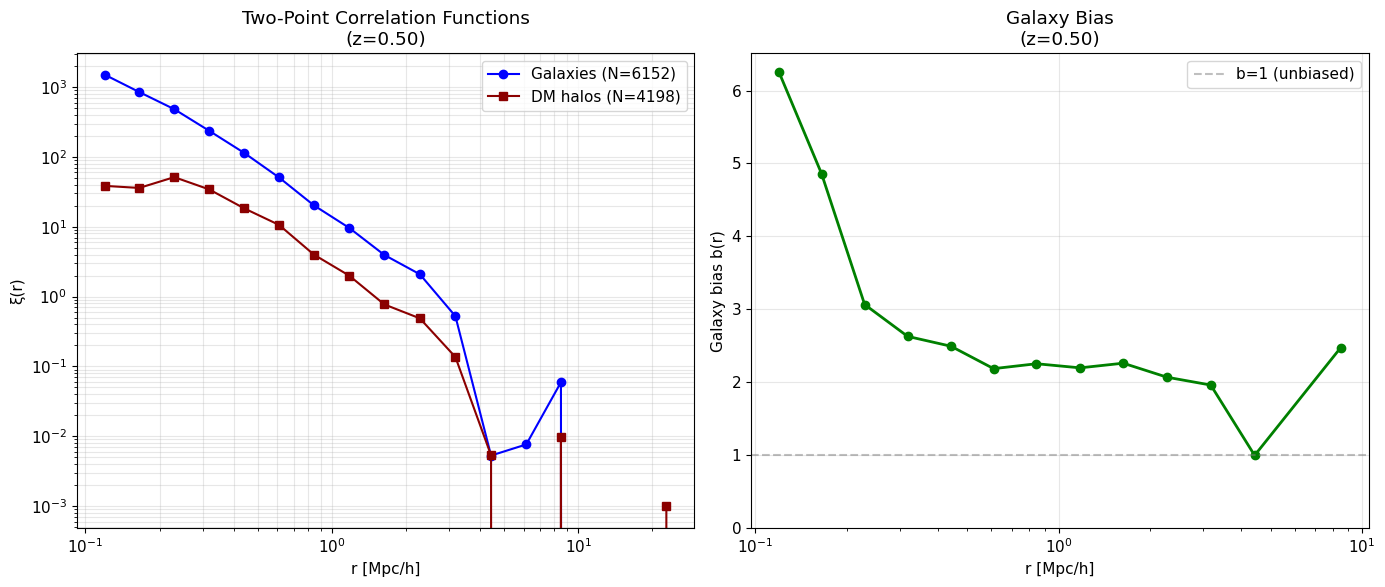

In [2]:
# Compute galaxy bias for a single snapshot and subvolume
example_snapshot = 'iz207'
example_ivol = 100
snap_path = str(base_dir / example_snapshot)

# Define bin edges
rbins = np.logspace(np.log10(0.1), np.log10(50.0), 20)

# Optional: apply minimum halo mass cut
mhalo_min = 1e11  # Msun

print(f"Computing galaxy bias for {example_snapshot}, subvolume {example_ivol}")
print(f"Mass cut: M_halo >= {mhalo_min:.1e} Msun\n")

result = compute_galaxy_bias(
    iz_path=snap_path,
    ivol=example_ivol,
    rbins=rbins,
    nthreads=4,
    mhalo_min=mhalo_min,
)

if result is not None:
    print(f"Results:")
    print(f"  Redshift: {result['z']:.4f}")
    print(f"  N_galaxies: {result['ngal']}")
    print(f"  N_halos: {result['nhalo']}")
    print(f"  Ratio: {result['ngal'] / result['nhalo']:.2f} galaxies per halo")
    print(f"  Boxsize: {result['boxsize']:.1f} Mpc/h\n")
    
    r = result['r']
    bias = result['bias']
    xi_gal = result['xi_gal']
    xi_dm = result['xi_dm']
    
    # Print table
    mask = np.isfinite(bias)
    print(f"  {'r [Mpc/h]':>12}  {'ξ_gal(r)':>12}  {'ξ_DM(r)':>12}  {'bias':>8}")
    print("  " + "-" * 50)
    for i in range(len(r)):
        if mask[i]:
            print(f"  {r[i]:12.2f}  {xi_gal[i]:12.6f}  {xi_dm[i]:12.6f}  {bias[i]:8.3f}")
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: Correlation functions
    ax = axes[0]
    ax.loglog(r, xi_gal, 'o-', color='blue', label=f'Galaxies (N={result["ngal"]})', markersize=6)
    ax.loglog(r, xi_dm, 's-', color='darkred', label=f'DM halos (N={result["nhalo"]})', markersize=6)
    ax.set_xlabel('r [Mpc/h]')
    ax.set_ylabel('ξ(r)')
    ax.set_title(f'Two-Point Correlation Functions\n(z={result["z"]:.2f})')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend()
    
    # Right: Galaxy bias
    ax = axes[1]
    ax.semilogx(r[mask], bias[mask], 'o-', color='green', markersize=6, linewidth=2)
    ax.axhline(1, color='gray', linestyle='--', alpha=0.5, label='b=1 (unbiased)')
    ax.set_xlabel('r [Mpc/h]')
    ax.set_ylabel('Galaxy bias b(r)')
    ax.set_title(f'Galaxy Bias\n(z={result["z"]:.2f})')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.show()
else:
    print("Failed to compute galaxy bias")

## Galaxy Bias Averaged Over Multiple Subvolumes

Computing average galaxy bias for iz207
Subvolumes: [40, 60, 100]
Mass cut: M_halo >= 1.0e+11 Msun

Results:
  Redshift: 0.4959
  Subvolumes used: 3/3

     r [Mpc/h]      bias       std
  --------------------------------
          0.12     6.844     0.495
          0.17     5.014     0.651
          0.23     3.396     0.392
          0.32     2.879     0.401
          0.44     2.650     0.328
          0.62     2.642     0.533
          0.84     2.652     0.592
          1.17     2.389     0.339
          1.64     2.479     0.225
          2.27     2.246     0.154
          3.16     2.122     0.317
          4.41     1.969     0.711
          6.12     2.092     0.000
          8.50     2.243     0.231
         11.83     2.178     0.000
         22.75     1.443     0.000


/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/analysis/correlation/galaxy_bias.py:133: RuntimeWarning: Mean of empty slice
  bias_mean = np.nanmean(bias_stack, axis=0)
/cosma/home/durham/dc-hick2/galform_analysis/.venv/lib64/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


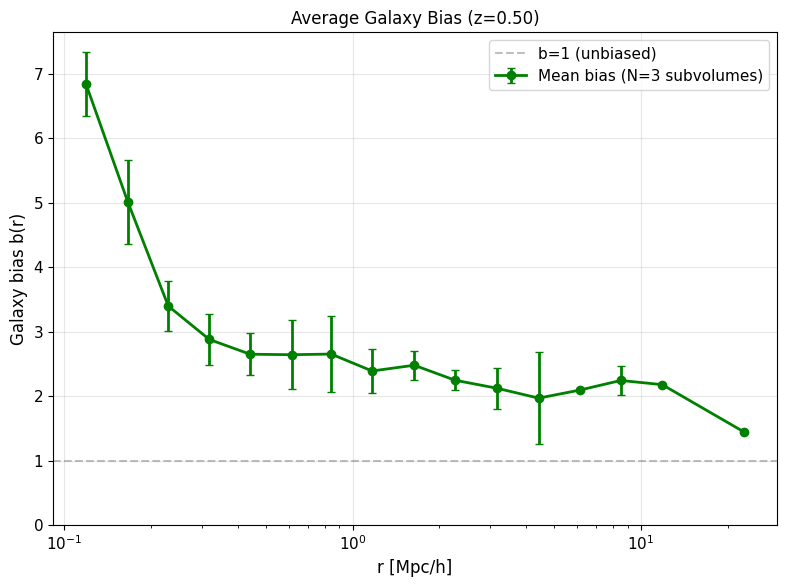

In [3]:
# Compute average galaxy bias over multiple subvolumes
example_snapshot = 'iz207'
snap_path = str(base_dir / example_snapshot)
example_ivols = [40, 60, 100]  # Multiple subvolumes

print(f"Computing average galaxy bias for {example_snapshot}")
print(f"Subvolumes: {example_ivols}")
print(f"Mass cut: M_halo >= {mhalo_min:.1e} Msun\n")

avg_result = avg_galaxy_bias_over_subvolumes(
    iz_path=snap_path,
    ivols=example_ivols,
    rbins=rbins,
    nthreads=4,
    mhalo_min=mhalo_min,
)

if avg_result is not None:
    print(f"Results:")
    print(f"  Redshift: {avg_result['z']:.4f}")
    print(f"  Subvolumes used: {avg_result['n_used']}/{avg_result['n_requested']}\n")
    
    r = avg_result['r']
    bias = avg_result['bias']
    bias_std = avg_result['bias_std']
    
    # Print table
    mask = np.isfinite(bias)
    print(f"  {'r [Mpc/h]':>12}  {'bias':>8}  {'std':>8}")
    print("  " + "-" * 32)
    for i in range(len(r)):
        if mask[i]:
            print(f"  {r[i]:12.2f}  {bias[i]:8.3f}  {bias_std[i]:8.3f}")
    
    # Plot average bias with error bars
    plt.figure(figsize=(8, 6))
    plt.errorbar(r[mask], bias[mask], yerr=bias_std[mask], 
                 fmt='o-', color='green', markersize=6, linewidth=2,
                 capsize=3, label=f'Mean bias (N={avg_result["n_used"]} subvolumes)')
    plt.axhline(1, color='gray', linestyle='--', alpha=0.5, label='b=1 (unbiased)')
    plt.xscale('log')
    plt.xlabel('r [Mpc/h]', fontsize=12)
    plt.ylabel('Galaxy bias b(r)', fontsize=12)
    plt.title(f'Average Galaxy Bias (z={avg_result["z"]:.2f})', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()
else:
    print("Failed to compute average galaxy bias")

## Galaxy Bias Evolution with Redshift

Computing galaxy bias evolution with redshift
Snapshots: ['iz100', 'iz120', 'iz142', 'iz176', 'iz207']
Subvolume: 100



Traceback (most recent call last):
  File "/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/analysis/correlation/correlation.py", line 220, in correlation_given_redshift_and_subvolume
    pos, z_val = _load_positions_from_hdf5(iz_path, ivol, centrals_only=centrals_only, mhalo_min=mhalo_min)
  File "/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/analysis/correlation/correlation.py", line 31, in _load_positions_from_hdf5
    raise FileNotFoundError(f"Missing or unreadable galaxies.hdf5 at {iz_path}/ivol{ivol}")
FileNotFoundError: Missing or unreadable galaxies.hdf5 at /cosma5/data/durham/dc-hick2/Galform_Out/L800/gp14/iz100/ivol100
Traceback (most recent call last):
  File "/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/analysis/correlation/correlation.py", line 220, in correlation_given_redshift_and_subvolume
    pos, z_val = _load_positions_from_hdf5(iz_path, ivol, centrals_only=centrals_only, mhalo_min=mhalo_min)
  File "/cosma/ho

  iz176: z=1.007, N_gal=5558, N_halo=4085
  iz207: z=0.496, N_gal=6152, N_halo=4198


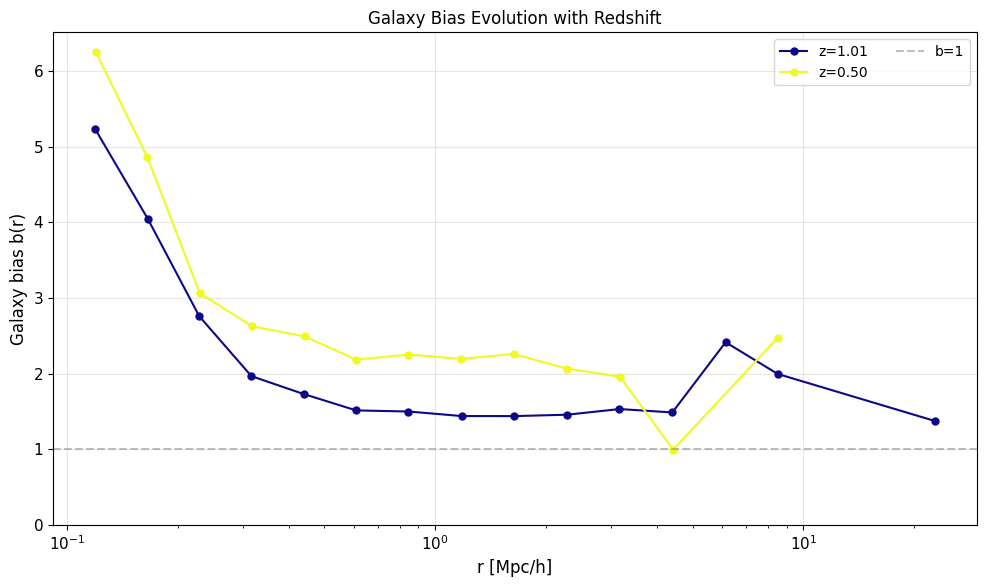

In [5]:
# Compute galaxy bias at multiple redshifts
iz_nums = [100, 120, 142, 176, 207]
example_ivol = 100

print("Computing galaxy bias evolution with redshift")
print(f"Snapshots: {[f'iz{iz}' for iz in iz_nums]}")
print(f"Subvolume: {example_ivol}\n")

results = []
for iz_num in iz_nums:
    snap_path = str(base_dir / f'iz{iz_num}')
    res = compute_galaxy_bias(
        iz_path=snap_path,
        ivol=example_ivol,
        rbins=rbins,
        nthreads=4,
        mhalo_min=mhalo_min,
    )
    if res is not None:
        results.append(res)
        print(f"  iz{iz_num}: z={res['z']:.3f}, N_gal={res['ngal']}, N_halo={res['nhalo']}")

if results:
    # Plot bias vs scale for different redshifts
    plt.figure(figsize=(10, 6))
    cmap = plt.cm.plasma
    colors = [cmap(i / (len(results) - 1)) for i in range(len(results))]
    
    for i, res in enumerate(results):
        r = res['r']
        bias = res['bias']
        mask = np.isfinite(bias)
        plt.semilogx(r[mask], bias[mask], 'o-', color=colors[i], 
                     label=f"z={res['z']:.2f}", markersize=5, linewidth=1.5)
    
    plt.axhline(1, color='gray', linestyle='--', alpha=0.5, label='b=1')
    plt.xlabel('r [Mpc/h]', fontsize=12)
    plt.ylabel('Galaxy bias b(r)', fontsize=12)
    plt.title('Galaxy Bias Evolution with Redshift', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10, ncol=2)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()
else:
    print("No successful bias calculations")